# Step 1: Environment Setup

In [4]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [5]:
!pip install tensorflow
import tensorflow as tf
print(tf.__version__)

Defaulting to user installation because normal site-packages is not writeable2.21.0



In [6]:
import os
print(os.getcwd())

C:\Users\radha\OneDrive\Desktop\Skin_cancer_project


# Step 2: Dataset Collection

### Step 3: Data Loading & Exploration

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("hmnist_28_28_RGB.csv")
df.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [9]:
print(df.shape)

(10015, 2353)


In [10]:
df['label'].value_counts()

label
4    6705
6    1113
2    1099
1     514
0     327
5     142
3     115
Name: count, dtype: int64

(-0.5, 27.5, 27.5, -0.5)

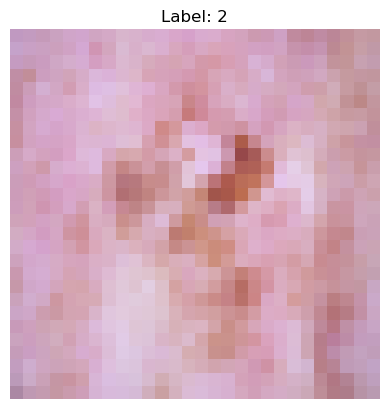

In [11]:
img = df.iloc[0, :-1].values.reshape(28, 28, 3)
plt.imshow(img)
plt.title(f"Label: {df.iloc[0, -1]}")
plt.axis('off')

## Step 4 — Preprocessing

### Separate features and labels

In [12]:
X = df.drop('label', axis=1)
y = df['label']

### Normalize data

In [13]:
X = X / 255.0

### Reshape data

In [14]:
X = X.values.reshape(-1, 28, 28, 3)

### Train/Test split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Check shapes

In [16]:
print(X_train.shape)
print(X_test.shape)

(8012, 28, 28, 3)
(2003, 28, 28, 3)


## Step 5 — CNN Model Building

### Import required modules

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

### Build CNN model

In [18]:
# CNN Model Building

model = Sequential()

# Input Layer (FIX)
model.add(Input(shape=(28,28,3)))

# 1st Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer (7 classes)
model.add(Dense(7, activation='softmax'))

### Compile model

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,223 (879.78 KB)

 Trainable params: 225,223 (879.78 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
Dense(128)

<Dense name=dense_2, built=False>

## Step 6 — Training

In [22]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6684 - loss: 1.0307 - val_accuracy: 0.6745 - val_loss: 0.9152
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6744 - loss: 0.9163 - val_accuracy: 0.6730 - val_loss: 0.8641
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6755 - loss: 0.8841 - val_accuracy: 0.6870 - val_loss: 0.8903
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6908 - loss: 0.8487 - val_accuracy: 0.6905 - val_loss: 0.8499
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6950 - loss: 0.8233 - val_accuracy: 0.6960 - val_loss: 0.8250
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7043 - loss: 0.7995 - val_accuracy: 0.6955 - val_loss: 0.8220
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7089 - loss: 0.7702 - val_accuracy: 0.7044 - val_loss: 0.7829
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7182 - loss: 0.7485 - val_accuracy: 

## Step 7 — Graph Visualization

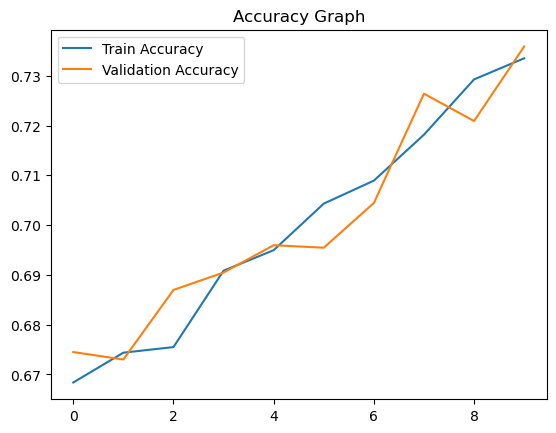

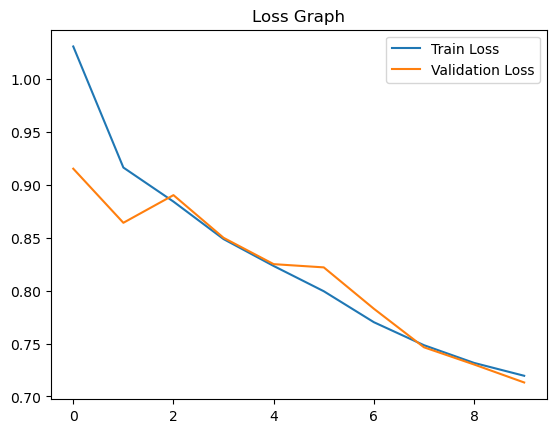

In [23]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

## Step 8 — Evaluation (Confusion Matrix + Report)

### Predictions

In [24]:
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


### Import metrics

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

### Confusion Matrix

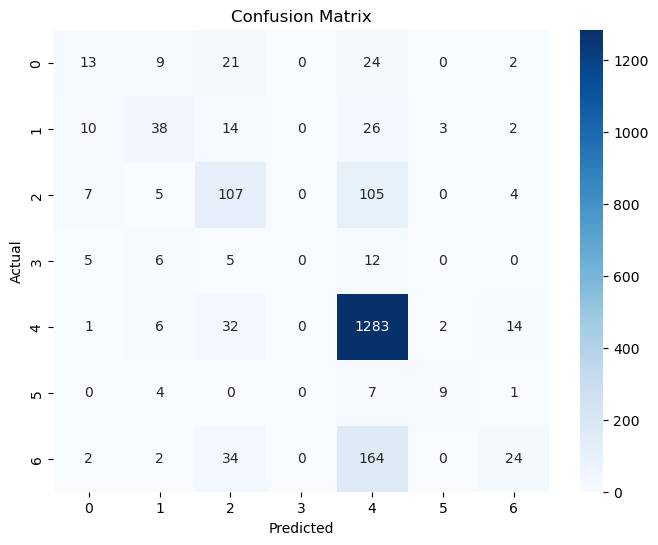

In [26]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Classification Report

In [27]:
print(classification_report(y_test, y_pred_classes, zero_division=0))

              precision    recall  f1-score   support

           0       0.34      0.19      0.24        69
           1       0.54      0.41      0.47        93
           2       0.50      0.47      0.49       228
           3       0.00      0.00      0.00        28
           4       0.79      0.96      0.87      1338
           5       0.64      0.43      0.51        21
           6       0.51      0.11      0.18       226

    accuracy                           0.74      2003
   macro avg       0.48      0.37      0.39      2003
weighted avg       0.69      0.74      0.69      2003



## Step 9 — Predict single image

In [28]:
import numpy as np

# Pick one test image
sample = X_test[0]

# Add batch dimension
sample = np.expand_dims(sample, axis=0)

# Predict
prediction = model.predict(sample)
predicted_class = np.argmax(prediction)

# Class names mapping
class_names = [
    "Melanocytic nevi",
    "Melanoma",
    "Benign keratosis-like lesions",
    "Basal cell carcinoma",
    "Actinic keratoses",
    "Vascular lesions",
    "Dermatofibroma"
]

print("Predicted Class:", predicted_class)
print("Predicted Label:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Class: 2
Predicted Label: Benign keratosis-like lesions


In [29]:
model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


array([[7.5989582e-02, 8.6185820e-03, 6.4494765e-01, 5.7489108e-03,
        1.5161189e-01, 2.3492852e-05, 1.1305997e-01]], dtype=float32)

# Step 10: Final Prediction System

Conclusion:

This project successfully builds a CNN model to classify skin cancer images into 7 categories.
The model achieved around 72% accuracy.
However, performance is affected by class imbalance, especially for minority classes.
Future improvements can include data augmentation and class balancing techniques.